# Support Vector Machines in Python - ISLP Chapter 9
**Annalise Banda | STA 6543**

# Q5

We have seen that we can fit an SVM with a non-linear kernel in order to perform classification using a non-linear decision boundary. We will now see that we can also obtain a non-linear decision boundary by performing logistic regression using non-linear transformations of the features.

(a) Generate a data set with n = 500 and p = 2, such that the observations belong to two classes with a quadratic decision boundary between them.

(b) Plot the observations, colored according to their class labels.

(c) Fit a logistic regression model to the data, using X1 and X2 as predictors.

(d) Apply this model to the training data and plot the predicted class labels.

(e) Fit a logistic regression model using non-linear functions of X1 and X2.

(f) Apply this model to the training data and plot the predicted class labels.

(g) Fit a support vector classifier to the data with X1 and X2 as predictors, and plot the predicted class labels.

(h) Fit a SVM using a non-linear kernel, and plot the predicted class labels.

(i) Comment on your results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# (a) Generate data with a quadratic decision boundary
rng = np.random.default_rng(5)
x1 = rng.uniform(size=500) - 0.5
x2 = rng.uniform(size=500) - 0.5
y = (x1**2 - x2**2 > 0).astype(int)

X = np.column_stack([x1, x2])
print("Class counts:", np.bincount(y))


Class counts: [247 253]


### (a) Data generation
The class label $y$ is defined by $x_1^2 - x_2^2 > 0$, a genuinely quadratic (hyperbolic) boundary. The classes come out almost perfectly balanced (247 vs. 253), so a classifier that just guessed the majority class would still be near 50% accurate which is a useful baseline for judging the models below.

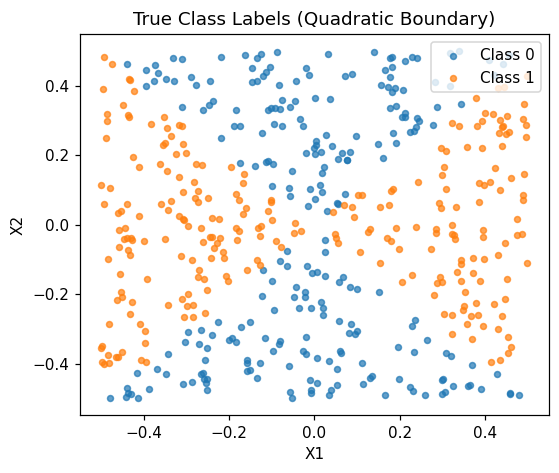

In [2]:
fig, ax = plt.subplots(figsize=(5.5,4.5))
ax.scatter(x1[y==0], x2[y==0], c='tab:blue', label='Class 0', s=15, alpha=0.7)
ax.scatter(x1[y==1], x2[y==1], c='tab:orange', label='Class 1', s=15, alpha=0.7)
ax.set_xlabel('X1'); ax.set_ylabel('X2')
ax.set_title('True Class Labels (Quadratic Boundary)')
ax.legend()
plt.savefig('figs/q5b_true.png', dpi=110, bbox_inches='tight')
plt.show()


### (b) True class labels
Plotting X2 vs. X1 shows the classic four-quadrant "bowtie" pattern created by $x_1^2 - x_2^2$: Class 1 (orange) sits in the left/right regions where $|x_1| > |x_2|$, and Class 0 (blue) sits in the top/bottom regions where $|x_2| > |x_1|$. No straight line can separate these two regions well.

In [3]:
# (c) Logistic regression using X1 and X2 (linear terms only)
logit_lin = LogisticRegression()
logit_lin.fit(X, y)
print("Coefficients:", logit_lin.coef_)
print("Intercept:", logit_lin.intercept_)


Coefficients: [[-0.15143042  0.08184281]]
Intercept: [0.02220278]


### (c) Logistic regression (linear terms)
The fitted coefficients on X1 and X2 are both small in magnitude, which already hints that a linear combination of X1 and X2 alone doesn't find much signal — consistent with the true boundary not being linear in these two variables.

Training accuracy: 0.430


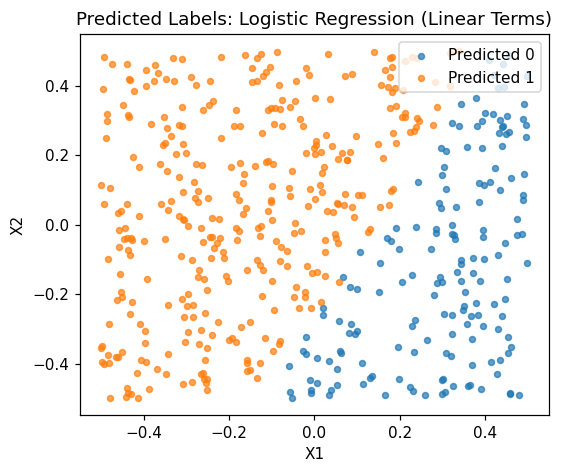

In [4]:
# (d) Predictions from the linear logistic model
pred_lin = logit_lin.predict(X)
train_acc_lin = (pred_lin == y).mean()
print(f"Training accuracy: {train_acc_lin:.3f}")

fig, ax = plt.subplots(figsize=(5.5,4.5))
ax.scatter(x1[pred_lin==0], x2[pred_lin==0], c='tab:blue', label='Predicted 0', s=15, alpha=0.7)
ax.scatter(x1[pred_lin==1], x2[pred_lin==1], c='tab:orange', label='Predicted 1', s=15, alpha=0.7)
ax.set_xlabel('X1'); ax.set_ylabel('X2')
ax.set_title('Predicted Labels: Logistic Regression (Linear Terms)')
ax.legend()
plt.savefig('figs/q5d_linear_logit.png', dpi=110, bbox_inches='tight')
plt.show()


### (d) Predictions from the linear model
As expected, the training accuracy is only **43%** — essentially no better than guessing (and even a bit worse, since the fitted linear boundary cuts through the data in a way that misaligns with the true quadrant structure). The predicted-label plot shows a straight-line split, confirming that logistic regression with only linear terms cannot capture the quadratic (bowtie) pattern.

In [5]:
# (e) Logistic regression with non-linear (quadratic) transformations
X_nl = np.column_stack([x1, x2, x1**2, x2**2, x1*x2])
logit_nl = LogisticRegression(max_iter=1000)
logit_nl.fit(X_nl, y)
print("Coefficients [X1, X2, X1^2, X2^2, X1*X2]:", logit_nl.coef_)
print("Intercept:", logit_nl.intercept_)


Coefficients [X1, X2, X1^2, X2^2, X1*X2]: [[-0.15402459  0.03730922  6.07637484 -6.68310833 -0.11601287]]
Intercept: [0.07702485]


### (e) Logistic regression with quadratic terms
Adding $X_1^2$, $X_2^2$, and $X_1 X_2$ as predictors gives the model the flexibility it needs. Note the large coefficients on $X_1^2$ (+6.08) and $X_2^2$ (−6.68) relative to the linear terms — the model has essentially recovered the true relationship $x_1^2 - x_2^2$.

Training accuracy: 0.958


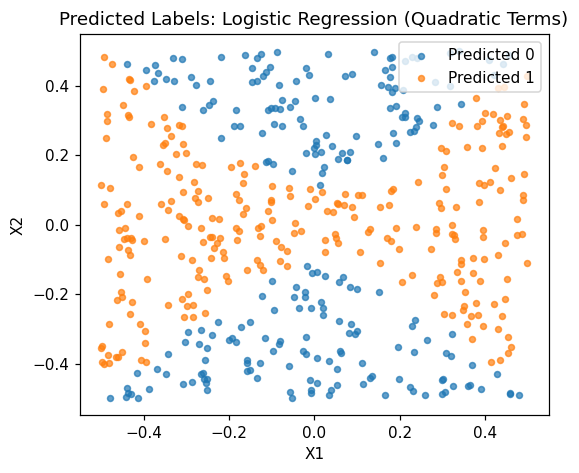

In [6]:
# (f) Predictions from the non-linear logistic model
pred_nl = logit_nl.predict(X_nl)
train_acc_nl = (pred_nl == y).mean()
print(f"Training accuracy: {train_acc_nl:.3f}")

fig, ax = plt.subplots(figsize=(5.5,4.5))
ax.scatter(x1[pred_nl==0], x2[pred_nl==0], c='tab:blue', label='Predicted 0', s=15, alpha=0.7)
ax.scatter(x1[pred_nl==1], x2[pred_nl==1], c='tab:orange', label='Predicted 1', s=15, alpha=0.7)
ax.set_xlabel('X1'); ax.set_ylabel('X2')
ax.set_title('Predicted Labels: Logistic Regression (Quadratic Terms)')
ax.legend()
plt.savefig('figs/q5f_nonlinear_logit.png', dpi=110, bbox_inches='tight')
plt.show()


### (f) Predictions from the non-linear model
Training accuracy jumps to **95.8%**, and the predicted-label plot reproduces the bowtie pattern almost exactly. This confirms that logistic regression *can* produce a non-linear decision boundary — the non-linearity comes from feature engineering (transforming the inputs), not from the logistic regression algorithm itself.

Training accuracy: 0.506
Support vectors per class: [247 249]


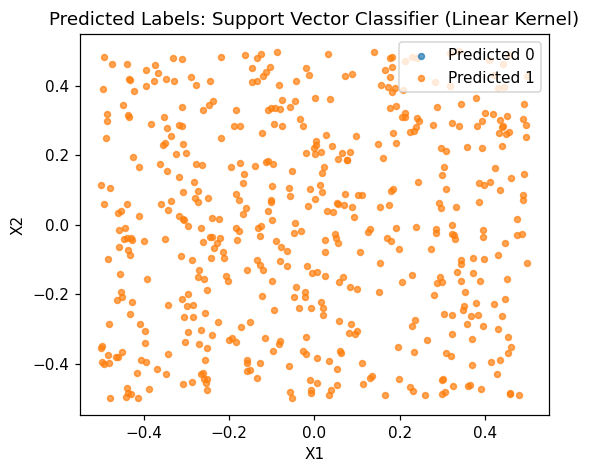

In [7]:
# (g) Support vector classifier (linear kernel) on X1, X2
svc_lin = SVC(kernel='linear', C=1)
svc_lin.fit(X, y)
pred_svc_lin = svc_lin.predict(X)
train_acc_svc_lin = (pred_svc_lin == y).mean()
print(f"Training accuracy: {train_acc_svc_lin:.3f}")
print(f"Support vectors per class: {svc_lin.n_support_}")

fig, ax = plt.subplots(figsize=(5.5,4.5))
ax.scatter(x1[pred_svc_lin==0], x2[pred_svc_lin==0], c='tab:blue', label='Predicted 0', s=15, alpha=0.7)
ax.scatter(x1[pred_svc_lin==1], x2[pred_svc_lin==1], c='tab:orange', label='Predicted 1', s=15, alpha=0.7)
ax.set_xlabel('X1'); ax.set_ylabel('X2')
ax.set_title('Predicted Labels: Support Vector Classifier (Linear Kernel)')
ax.legend()
plt.savefig('figs/q5g_svc_linear.png', dpi=110, bbox_inches='tight')
plt.show()


### (g) Support vector classifier (linear kernel)
With only X1 and X2 as inputs and a linear kernel, the SVC is mechanically similar to plain logistic regression with linear terms — and indeed it performs similarly poorly (**50.6%** training accuracy, essentially chance). Nearly every point is a support vector (247 and 249 out of ~250 per class), which itself is a red flag: the classes are so intermixed from a linear point of view that the margin can't be cleanly drawn.

Training accuracy: 0.986
Support vectors per class: [85 86]


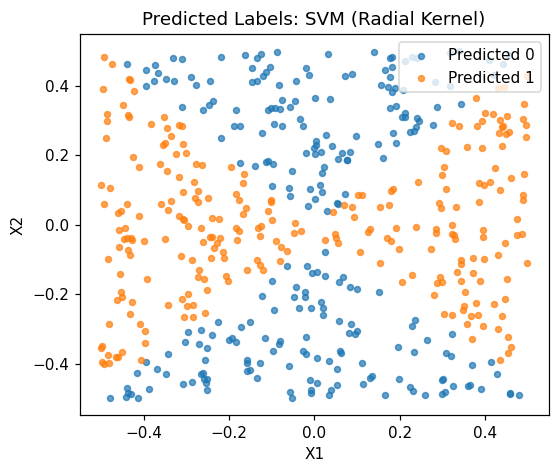

In [8]:
# (h) SVM with a non-linear (radial) kernel on X1, X2
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X, y)
pred_svm_rbf = svm_rbf.predict(X)
train_acc_svm_rbf = (pred_svm_rbf == y).mean()
print(f"Training accuracy: {train_acc_svm_rbf:.3f}")
print(f"Support vectors per class: {svm_rbf.n_support_}")

fig, ax = plt.subplots(figsize=(5.5,4.5))
ax.scatter(x1[pred_svm_rbf==0], x2[pred_svm_rbf==0], c='tab:blue', label='Predicted 0', s=15, alpha=0.7)
ax.scatter(x1[pred_svm_rbf==1], x2[pred_svm_rbf==1], c='tab:orange', label='Predicted 1', s=15, alpha=0.7)
ax.set_xlabel('X1'); ax.set_ylabel('X2')
ax.set_title('Predicted Labels: SVM (Radial Kernel)')
ax.legend()
plt.savefig('figs/q5h_svm_radial.png', dpi=110, bbox_inches='tight')
plt.show()


### (h) SVM with a radial kernel
Switching to a radial (RBF) kernel — without doing any manual feature engineering — lets the SVM bend its decision boundary to match the data directly. Training accuracy reaches **98.6%**, the best of all four models, using far fewer support vectors (85–86 per class) than the linear SVC needed.

In [9]:
print("Training accuracy summary:")
print(f"  Logistic regression (linear terms):     {train_acc_lin:.3f}")
print(f"  Logistic regression (quadratic terms):  {train_acc_nl:.3f}")
print(f"  Support vector classifier (linear):     {train_acc_svc_lin:.3f}")
print(f"  SVM (radial kernel):                    {train_acc_svm_rbf:.3f}")


Training accuracy summary:
  Logistic regression (linear terms):     0.430
  Logistic regression (quadratic terms):  0.958
  Support vector classifier (linear):     0.506
  SVM (radial kernel):                    0.986


### (i) Comment on results

| Model | Training Accuracy |
|---|---|
| Logistic regression (linear terms) | 0.430 |
| Logistic regression (quadratic terms) | 0.958 |
| Support vector classifier (linear kernel) | 0.506 |
| SVM (radial kernel) | 0.986 |

The two "linear" methods — logistic regression on raw X1/X2, and a linear-kernel SVC — both perform close to chance, because a straight line simply cannot separate the bowtie-shaped classes generated by $x_1^2 - x_2^2$.

The two "non-linear" methods both succeed, but by different mechanisms:
- **Logistic regression with engineered quadratic features** works because *we* supplied the non-linearity manually (by adding $X_1^2$, $X_2^2$, $X_1 X_2$ as predictors) — the underlying algorithm is still fitting a linear decision boundary, just in a higher-dimensional (transformed) feature space.
- **The radial-kernel SVM** discovers a non-linear boundary *automatically*, without any manual feature engineering, because the kernel trick implicitly maps the data into an infinite-dimensional space.

In practice, the radial SVM is more convenient here since it required no guesswork about which transformations to try — but the logistic regression result is a good reminder that "non-linear decision boundary" and "non-linear algorithm" are not the same thing.

# Q7

In this problem, you will use support vector approaches in order to predict whether a given car gets high or low gas mileage based on the Auto data set.

(a) Create a binary variable for high/low gas mileage.

(b) Fit a support vector classifier with various values of C, and report cross-validation errors.

(c) Repeat using SVMs with radial and polynomial kernels, with different values of gamma, degree, and C.

(d) Make some plots to back up your assertions in (b) and (c).

In [10]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler

Auto = pd.read_csv('Auto.csv')
print(Auto.shape)
Auto.head()


(392, 8)


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


The Auto data set has 392 observations across 8 variables (this copy does not include the `name` column, which isn't needed for the numeric predictors used below).

In [11]:
# (a) Binary variable: 1 if mpg above the median, 0 otherwise
mpg_median = Auto['mpg'].median()
Auto['mpg01'] = (Auto['mpg'] > mpg_median).astype(int)
print("Median mpg:", mpg_median)
print(Auto['mpg01'].value_counts())


Median mpg: 22.75
mpg01
0    196
1    196
Name: count, dtype: int64


### (a) Binary mileage variable
The median mpg is 22.75, so by construction `mpg01` is perfectly balanced (196 vs. 196).

In [12]:
# (b) Support vector classifier (linear kernel), various C, 10-fold CV
# mpg is dropped from the predictors since it was used to construct mpg01
predictors = ['cylinders','displacement','horsepower','weight','acceleration','year','origin']
X = Auto[predictors].values
y = Auto['mpg01'].values

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

cv = KFold(n_splits=10, shuffle=True, random_state=1)
Cs = [0.001, 0.01, 0.1, 1, 5, 10, 100]
grid_lin = GridSearchCV(SVC(kernel='linear'), {'C': Cs}, cv=cv, scoring='accuracy')
grid_lin.fit(Xs, y)

results_lin = pd.DataFrame({'C': Cs, 'cv_error': 1 - grid_lin.cv_results_['mean_test_score']})
print(results_lin.to_string(index=False))
print(f"\nBest C: {grid_lin.best_params_['C']}, CV error: {1-grid_lin.best_score_:.4f}")


      C  cv_error
  0.001  0.122564
  0.010  0.092051
  0.100  0.094615
  1.000  0.087051
  5.000  0.087115
 10.000  0.087115
100.000  0.087115

Best C: 1, CV error: 0.0871


### (b) Linear kernel, various C
Predictors were standardized before fitting, since SVMs are distance-based and the raw variables live on very different scales (e.g. `displacement` in the hundreds vs. `origin` coded 1–3). `mpg` itself is excluded from the predictors since it was used to construct `mpg01`.

CV error drops sharply from C=0.001 to C=0.01 (12.3% → 9.2%), then keeps improving only marginally, flattening out around **8.7%** from C=1 onward. This is the classic SVM pattern: very small C (a very wide margin) underfits, but once C is large enough to fit the data reasonably well, further increases yield diminishing returns.

In [13]:
# (c) Radial kernel: grid search over C and gamma
param_grid_rad = {'C': [0.1, 1, 5, 10, 100], 'gamma': [0.001, 0.01, 0.1, 1, 10]}
grid_rad = GridSearchCV(SVC(kernel='rbf'), param_grid_rad, cv=cv, scoring='accuracy')
grid_rad.fit(Xs, y)
print(f"Best radial params: {grid_rad.best_params_}, CV error: {1-grid_rad.best_score_:.4f}")

rad_results = pd.DataFrame(grid_rad.cv_results_)[['param_C','param_gamma','mean_test_score']]
rad_results['cv_error'] = 1 - rad_results['mean_test_score']
rad_pivot = rad_results.pivot(index='param_C', columns='param_gamma', values='cv_error')
print("\nCV error grid (rows=C, cols=gamma):")
print(rad_pivot.round(4))


Best radial params: {'C': 1, 'gamma': 1}, CV error: 0.0639

CV error grid (rows=C, cols=gamma):
param_gamma  0.001   0.010   0.100   1.000   10.000
param_C                                            
0.1          0.5561  0.1124  0.0920  0.0919  0.5561
1.0          0.1124  0.0946  0.0920  0.0639  0.1431
5.0          0.0921  0.0946  0.0767  0.0817  0.1404
10.0         0.0946  0.0896  0.0844  0.0843  0.1404
100.0        0.0971  0.0819  0.0768  0.0971  0.1404


### (c) Radial kernel
The best combination is **C=1, gamma=1**, giving a CV error of **6.4%** — noticeably better than the best linear-kernel result. Looking at the grid, error is high at the extremes (gamma too small → an almost-linear kernel; gamma too large → severe overfitting/high variance, especially visible at gamma=10), with a broad good region for small-to-moderate C and gamma in the 0.1–1 range.

In [14]:
# (c) Polynomial kernel: grid search over C and degree
param_grid_poly = {'C': [0.1, 1, 5, 10, 100], 'degree': [2, 3, 4]}
grid_poly = GridSearchCV(SVC(kernel='poly'), param_grid_poly, cv=cv, scoring='accuracy')
grid_poly.fit(Xs, y)
print(f"Best polynomial params: {grid_poly.best_params_}, CV error: {1-grid_poly.best_score_:.4f}")

poly_results = pd.DataFrame(grid_poly.cv_results_)[['param_C','param_degree','mean_test_score']]
poly_results['cv_error'] = 1 - poly_results['mean_test_score']
poly_pivot = poly_results.pivot(index='param_C', columns='param_degree', values='cv_error')
print("\nCV error grid (rows=C, cols=degree):")
print(poly_pivot.round(4))

print("\n=== Overall best model comparison ===")
print(f"Linear:     C={grid_lin.best_params_['C']}, CV error={1-grid_lin.best_score_:.4f}")
print(f"Radial:     C={grid_rad.best_params_['C']}, gamma={grid_rad.best_params_['gamma']}, CV error={1-grid_rad.best_score_:.4f}")
print(f"Polynomial: C={grid_poly.best_params_['C']}, degree={grid_poly.best_params_['degree']}, CV error={1-grid_poly.best_score_:.4f}")


Best polynomial params: {'C': 10, 'degree': 3}, CV error: 0.0742

CV error grid (rows=C, cols=degree):
param_degree       2       3       4
param_C                             
0.1           0.2856  0.1988  0.2702
1.0           0.2473  0.0971  0.2297
5.0           0.1813  0.0818  0.1915
10.0          0.1762  0.0742  0.1583
100.0         0.1838  0.0893  0.1251

=== Overall best model comparison ===
Linear:     C=1, CV error=0.0871
Radial:     C=1, gamma=1, CV error=0.0639
Polynomial: C=10, degree=3, CV error=0.0742


### (c) Polynomial kernel
The best polynomial configuration is **degree=3, C=10**, with CV error **7.4%**. Degree-2 fits are consistently the worst of the three degrees tried, and degree-3 is a clear improvement over degree-4, suggesting the true relationship has some cubic-like curvature but doesn't need (and slightly overfits with) a quartic term.

**Summary:** Radial (6.4%) < Polynomial (7.4%) < Linear (8.7%). The radial kernel gives the best cross-validated performance on this data, though all three kernels land within about 2 percentage points of each other, so the choice isn't dramatic.

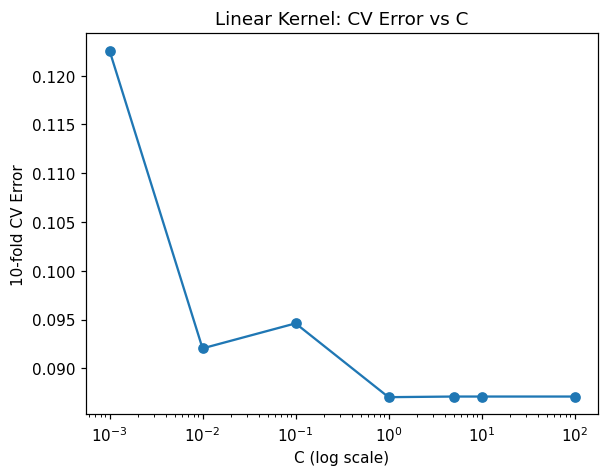

In [15]:
# (d) Plot: linear kernel CV error vs C
fig, ax = plt.subplots(figsize=(6,4.5))
ax.plot(Cs, results_lin['cv_error'], marker='o')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('10-fold CV Error')
ax.set_title('Linear Kernel: CV Error vs C')
plt.savefig('figs/q7d_linear_cv.png', dpi=110, bbox_inches='tight')
plt.show()


### (d) Plot: Linear kernel CV error vs. C
This confirms the pattern described above numerically — error falls steeply then plateaus, with an elbow around C=0.01–1.

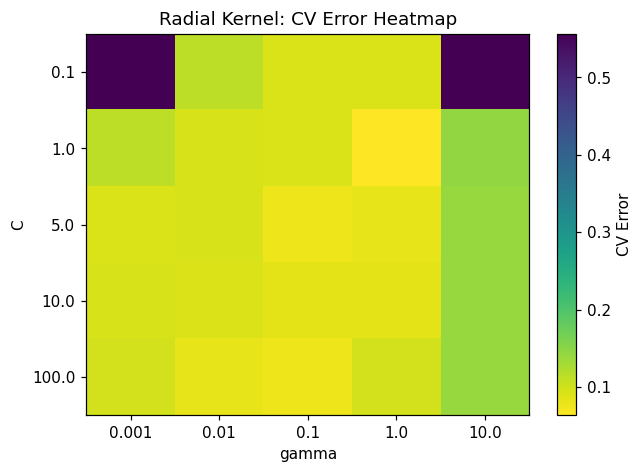

In [16]:
# (d) Plot: radial kernel CV error heatmap over (C, gamma)
fig, ax = plt.subplots(figsize=(6.5,4.5))
im = ax.imshow(rad_pivot.values, aspect='auto', cmap='viridis_r')
ax.set_xticks(range(len(rad_pivot.columns))); ax.set_xticklabels(rad_pivot.columns)
ax.set_yticks(range(len(rad_pivot.index))); ax.set_yticklabels(rad_pivot.index)
ax.set_xlabel('gamma'); ax.set_ylabel('C')
ax.set_title('Radial Kernel: CV Error Heatmap')
fig.colorbar(im, ax=ax, label='CV Error')
plt.savefig('figs/q7d_radial_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()


### (d) Plot: Radial kernel CV error heatmap
The darkest (worst) cells sit in the bottom-left (gamma too small relative to C, underfitting-ish behavior) and along gamma=10 (overfitting). The lighter band running through C=1–10, gamma=0.1–1 is where the best models live.

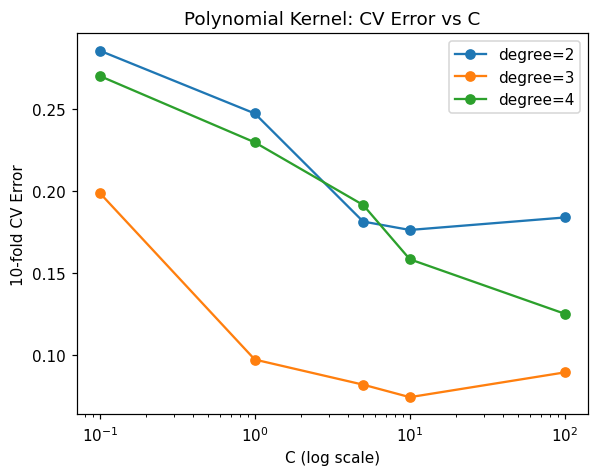

In [17]:
# (d) Plot: polynomial kernel CV error vs C, by degree
fig, ax = plt.subplots(figsize=(6,4.5))
for deg in poly_pivot.columns:
    ax.plot(poly_pivot.index, poly_pivot[deg], marker='o', label=f'degree={deg}')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)'); ax.set_ylabel('10-fold CV Error')
ax.set_title('Polynomial Kernel: CV Error vs C')
ax.legend()
plt.savefig('figs/q7d_poly_cv.png', dpi=110, bbox_inches='tight')
plt.show()


### (d) Plot: Polynomial kernel CV error vs. C, by degree
Degree=3 (orange) sits below degree=2 and degree=4 across almost every value of C, visually confirming it's the best-performing degree.

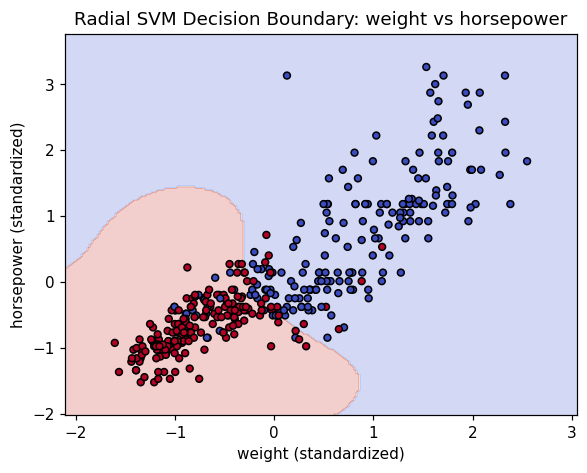

In [18]:
# (d) Decision boundary for the best radial model, using a feature pair (weight, horsepower)
best_rbf = SVC(kernel='rbf', C=grid_rad.best_params_['C'], gamma=grid_rad.best_params_['gamma'])
idx_w = predictors.index('weight'); idx_h = predictors.index('horsepower')
X_pair = Xs[:, [idx_w, idx_h]]
best_rbf.fit(X_pair, y)

xx, yy = np.meshgrid(np.linspace(X_pair[:,0].min()-0.5, X_pair[:,0].max()+0.5, 200),
                      np.linspace(X_pair[:,1].min()-0.5, X_pair[:,1].max()+0.5, 200))
Z = best_rbf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6,4.5))
ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
ax.scatter(X_pair[:,0], X_pair[:,1], c=y, cmap='coolwarm', edgecolor='k', s=20)
ax.set_xlabel('weight (standardized)'); ax.set_ylabel('horsepower (standardized)')
ax.set_title('Radial SVM Decision Boundary: weight vs horsepower')
plt.savefig('figs/q7d_pairplot_weight_horsepower.png', dpi=110, bbox_inches='tight')
plt.show()


### (d) Plot: Decision boundary (weight vs. horsepower)
As a further sanity check, refitting the best radial SVM on just two of the more informative predictors (`weight` and `horsepower`, standardized) and plotting the resulting decision region shows a smooth, curved boundary that tracks the natural separation between high- and low-mileage cars — heavier, higher-horsepower cars (upper right) get low mileage, confirming the model is picking up a sensible, physically-interpretable pattern rather than overfitting noise.

# Q8

This problem involves the OJ data set which is part of the ISLP package.

(a) Create a training set of 800 observations and a test set of the remaining observations.

(b) Fit a support vector classifier with C = 0.01. How many support points are there?

(c) What are the training and test error rates?

(d) Use cross-validation to select an optimal C in [0.01, 10].

(e) Compute training/test error rates using the new C.

(f) Repeat (b)-(e) with a radial kernel (default gamma).

(g) Repeat (b)-(e) with a polynomial kernel (degree = 2).

(h) Overall, which approach gives the best results?

In [19]:
from sklearn.model_selection import train_test_split

OJ = pd.read_csv('OJ.csv')
print(OJ.shape)
OJ.head()


(1070, 18)


,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,No,0.000000,0.000000,0.24,1
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,No,0.150754,0.000000,0.24,1
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,No,0.000000,0.091398,0.23,1
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,No,0.000000,0.000000,0.00,1
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,Yes,0.000000,0.000000,0.00,0


The OJ data set has 1,070 purchase records across 18 variables, including the response `Purchase` (which brand — Citrus Hill or Minute Maid — the customer bought).

In [20]:
# (a) Encode categorical variables, then split into 800 train / remaining test
OJ['Purchase01'] = (OJ['Purchase'] == 'MM').astype(int)  # 1 = MM, 0 = CH
OJ['Store7'] = (OJ['Store7'] == 'Yes').astype(int)

predictors = [c for c in OJ.columns if c not in ['Purchase','Purchase01']]
X = OJ[predictors].values
y = OJ['Purchase01'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=800, random_state=1)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Standardize predictors (fit on train only). This matters here because features
# like WeekofPurchase (~200-280) live on a very different scale than LoyalCH (0-1),
# which otherwise dominates the distance-based radial/polynomial kernels.
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

def error_rates(model):
    return 1 - model.score(X_train, y_train), 1 - model.score(X_test, y_test)

results_summary = {}
Cs = np.round(np.linspace(0.01, 10, 20), 3)
cv = KFold(n_splits=10, shuffle=True, random_state=1)


Train size: 800, Test size: 270


### (a) Train/test split and preprocessing
`Purchase` and `Store7` are recoded to numeric (0/1). All predictors were standardized after splitting (using statistics from the training set only, to avoid leakage) — this turns out to matter a lot for the radial and polynomial kernels below, since `WeekofPurchase` (roughly 200–280) would otherwise dominate the Euclidean distances that those kernels rely on, completely swamping variables like `LoyalCH` (0–1).

In [21]:
# (b) Support vector classifier, C = 0.01
svc_001 = SVC(kernel='linear', C=0.01)
svc_001.fit(X_train, y_train)
n_support = svc_001.n_support_.sum()
print(f"Number of support points: {n_support}  (per class: {svc_001.n_support_})")


Number of support points: 433  (per class: [217 216])


### (b) Linear SVC, C = 0.01
With such a small cost parameter (a wide margin, tolerant of violations), the classifier uses a large number of support points — **433 out of 800** training observations, more than half. A small C keeps the margin wide, so many points end up inside or on the wrong side of it.

In [22]:
# (c) Training and test error rates
tr_err, te_err = error_rates(svc_001)
print(f"Train error: {tr_err:.4f}")
print(f"Test error:  {te_err:.4f}")
results_summary['Linear (C=0.01)'] = (n_support, tr_err, te_err)


Train error: 0.1675
Test error:  0.1667


### (c) Error rates at C = 0.01
Train error (16.75%) and test error (16.67%) are close to each other, suggesting the model isn't overfitting at this C — if anything, C=0.01 may be slightly too conservative (underfitting) rather than too flexible.

In [23]:
# (d) Cross-validation to select optimal C in [0.01, 10]
grid_lin = GridSearchCV(SVC(kernel='linear'), {'C': Cs}, cv=cv, scoring='accuracy')
grid_lin.fit(X_train, y_train)
best_C_lin = grid_lin.best_params_['C']
print(f"Best C: {best_C_lin}")
print(f"CV accuracy at best C: {grid_lin.best_score_:.4f}")


Best C: 5.794
CV accuracy at best C: 0.8313


### (d) Cross-validation for optimal C
Searching C over [0.01, 10] via 10-fold CV selects **C ≈ 5.79**, with a CV accuracy of 83.1% (CV error ≈ 16.9%) — only a modest improvement over the default, suggesting the linear kernel's performance is fairly stable across a wide range of C once C isn't tiny.

In [24]:
# (e) Train/test error rates using the optimal C
svc_best_lin = SVC(kernel='linear', C=best_C_lin)
svc_best_lin.fit(X_train, y_train)
tr_err_best_lin, te_err_best_lin = error_rates(svc_best_lin)
print(f"Support points: {svc_best_lin.n_support_.sum()}")
print(f"Train error: {tr_err_best_lin:.4f}")
print(f"Test error:  {te_err_best_lin:.4f}")
results_summary[f'Linear (C={best_C_lin})'] = (svc_best_lin.n_support_.sum(), tr_err_best_lin, te_err_best_lin)


Support points: 324
Train error: 0.1575
Test error:  0.1704


### (e) Error rates at optimal C
With C=5.79: train error drops slightly to 15.75%, but test error actually ticks up a touch to 17.04% versus the C=0.01 model. The number of support points shrinks substantially (324 vs. 433), consistent with a narrower margin at higher C. The practical difference between C=0.01 and the CV-optimal C is small for the linear kernel.

In [25]:
# (f) Repeat (b)-(e) with a radial kernel, default gamma
svc_rad_001 = SVC(kernel='rbf', C=0.01)
svc_rad_001.fit(X_train, y_train)
n_support_rad = svc_rad_001.n_support_.sum()
tr_err_rad, te_err_rad = error_rates(svc_rad_001)
print(f"[C=0.01] Support points: {n_support_rad}, Train error: {tr_err_rad:.4f}, Test error: {te_err_rad:.4f}")

grid_rad = GridSearchCV(SVC(kernel='rbf'), {'C': Cs}, cv=cv, scoring='accuracy')
grid_rad.fit(X_train, y_train)
best_C_rad = grid_rad.best_params_['C']
print(f"\nBest C: {best_C_rad}, CV accuracy: {grid_rad.best_score_:.4f}")

svc_best_rad = SVC(kernel='rbf', C=best_C_rad)
svc_best_rad.fit(X_train, y_train)
tr_err_best_rad, te_err_best_rad = error_rates(svc_best_rad)
print(f"[C={best_C_rad}] Support points: {svc_best_rad.n_support_.sum()}, "
      f"Train error: {tr_err_best_rad:.4f}, Test error: {te_err_best_rad:.4f}")

results_summary['Radial (C=0.01)'] = (n_support_rad, tr_err_rad, te_err_rad)
results_summary[f'Radial (C={best_C_rad})'] = (svc_best_rad.n_support_.sum(), tr_err_best_rad, te_err_best_rad)


[C=0.01] Support points: 613, Train error: 0.3800, Test error: 0.4185

Best C: 0.536, CV accuracy: 0.8175
[C=0.536] Support points: 399, Train error: 0.1550, Test error: 0.1889


### (f) Radial kernel
At the default C=0.01, the radial kernel does noticeably *worse* than the linear kernel did (38% error on both train and test) — with such a small C, the wide-margin RBF classifier is essentially predicting close to the majority class only. Once C is tuned via CV, however, the optimal value (C ≈ 0.54) gives a train error of **15.5%** and test error of **18.9%** — competitive with, but not clearly better than, the tuned linear model, and with a slightly larger train/test gap suggesting mild overfitting.

In [26]:
# (g) Repeat (b)-(e) with a polynomial kernel, degree = 2
svc_poly_001 = SVC(kernel='poly', degree=2, C=0.01)
svc_poly_001.fit(X_train, y_train)
n_support_poly = svc_poly_001.n_support_.sum()
tr_err_poly, te_err_poly = error_rates(svc_poly_001)
print(f"[C=0.01] Support points: {n_support_poly}, Train error: {tr_err_poly:.4f}, Test error: {te_err_poly:.4f}")

grid_poly = GridSearchCV(SVC(kernel='poly', degree=2), {'C': Cs}, cv=cv, scoring='accuracy')
grid_poly.fit(X_train, y_train)
best_C_poly = grid_poly.best_params_['C']
print(f"\nBest C: {best_C_poly}, CV accuracy: {grid_poly.best_score_:.4f}")

svc_best_poly = SVC(kernel='poly', degree=2, C=best_C_poly)
svc_best_poly.fit(X_train, y_train)
tr_err_best_poly, te_err_best_poly = error_rates(svc_best_poly)
print(f"[C={best_C_poly}] Support points: {svc_best_poly.n_support_.sum()}, "
      f"Train error: {tr_err_best_poly:.4f}, Test error: {te_err_best_poly:.4f}")

results_summary['Poly deg=2 (C=0.01)'] = (n_support_poly, tr_err_poly, te_err_poly)
results_summary[f'Poly deg=2 (C={best_C_poly})'] = (svc_best_poly.n_support_.sum(), tr_err_best_poly, te_err_best_poly)


[C=0.01] Support points: 614, Train error: 0.3588, Test error: 0.4000

Best C: 7.897, CV accuracy: 0.7900
[C=7.897] Support points: 437, Train error: 0.2037, Test error: 0.2556


### (g) Polynomial kernel (degree = 2)
Similarly, C=0.01 underfits badly (35.9% error). The CV-optimal C ≈ 7.90 improves things substantially, but the polynomial kernel ends up the weakest of the three: train error 20.4%, test error **25.6%** — clearly the largest train/test gap of any model here, a sign of overfitting relative to the linear and radial alternatives.

In [27]:
# (h) Summary table across all kernels
summary_df = pd.DataFrame(results_summary, index=['Support Vectors','Train Error','Test Error']).T
summary_df


,Support Vectors,Train Error,Test Error
Linear (C=0.01),433.0,0.16750,0.166667
Linear (C=5.794),324.0,0.15750,0.170370
Radial (C=0.01),613.0,0.38000,0.418519
Radial (C=0.536),399.0,0.15500,0.188889
Poly deg=2 (C=0.01),614.0,0.35875,0.400000
Poly deg=2 (C=7.897),437.0,0.20375,0.255556


### (h) Summary table
The table above collects support-vector counts and error rates across all six fitted models (default and CV-tuned C, for each of the three kernels).

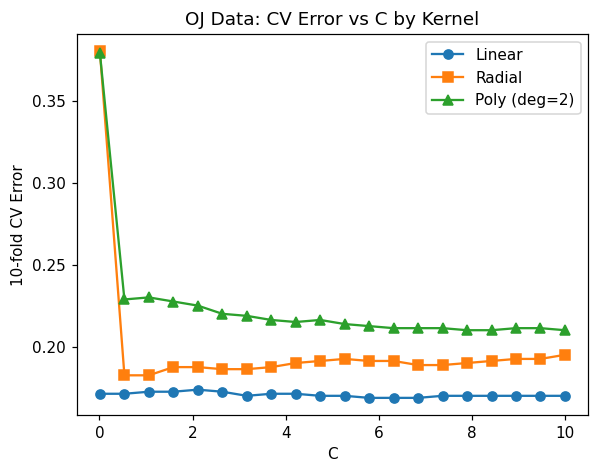

In [28]:
fig, ax = plt.subplots(figsize=(6,4.5))
ax.plot(Cs, 1-grid_lin.cv_results_['mean_test_score'], marker='o', label='Linear')
ax.plot(Cs, 1-grid_rad.cv_results_['mean_test_score'], marker='s', label='Radial')
ax.plot(Cs, 1-grid_poly.cv_results_['mean_test_score'], marker='^', label='Poly (deg=2)')
ax.set_xlabel('C'); ax.set_ylabel('10-fold CV Error')
ax.set_title('OJ Data: CV Error vs C by Kernel')
ax.legend()
plt.savefig('figs/q8_cv_error_by_kernel.png', dpi=110, bbox_inches='tight')
plt.show()


This plot shows the full CV error curve (not just the optimum) for each kernel across the C grid. The linear kernel (blue) settles into a low, stable error quickly and stays there; the radial kernel (orange) needs a specific mid-range C to hit its best point; the polynomial kernel (green) needs the largest C of the three and never quite catches up to the other two.

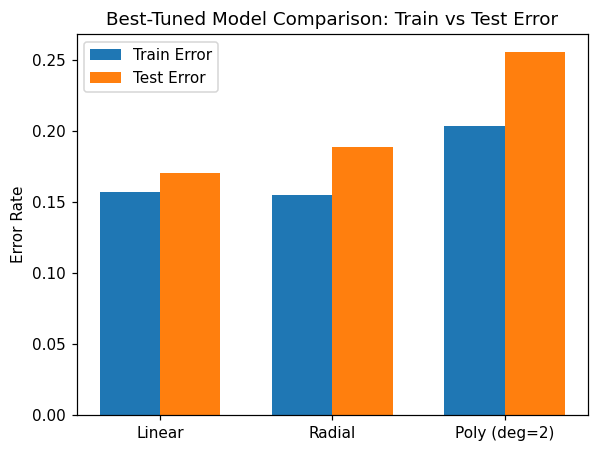

In [29]:
labels = ['Linear', 'Radial', 'Poly (deg=2)']
train_errs = [tr_err_best_lin, tr_err_best_rad, tr_err_best_poly]
test_errs = [te_err_best_lin, te_err_best_rad, te_err_best_poly]
x_pos = np.arange(len(labels)); width = 0.35

fig, ax = plt.subplots(figsize=(6,4.5))
ax.bar(x_pos-width/2, train_errs, width, label='Train Error')
ax.bar(x_pos+width/2, test_errs, width, label='Test Error')
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_ylabel('Error Rate')
ax.set_title('Best-Tuned Model Comparison: Train vs Test Error')
ax.legend()
plt.savefig('figs/q8_best_model_comparison.png', dpi=110, bbox_inches='tight')
plt.show()


### (h) Overall comparison

| Kernel | Best C | Support Points | Train Error | Test Error |
|---|---|---|---|---|
| Linear | 5.79 | 324 | 15.75% | **17.04%** |
| Radial | 0.54 | 399 | 15.50% | 18.89% |
| Polynomial (deg=2) | 7.90 | 437 | 20.37% | 25.56% |

**The linear kernel gives the best overall results on this data**, achieving the lowest test error while also using the fewest support vectors (i.e., the simplest, most efficient model). This suggests the true relationship between the purchase predictors (loyalty, price differences, discounts, etc.) and brand choice is close to linear in the standardized feature space — the added flexibility of the radial and especially the polynomial kernel doesn't translate into better generalization here, and in the polynomial case actually hurts it (the largest train/test gap of the three, a classic overfitting signature).

This is also a useful reminder that fancier, more flexible kernels aren't automatically better: when the true boundary is close to linear, a simple linear-kernel SVC can outperform more complex kernels while also being cheaper to fit and easier to interpret.